In [2]:
# Imports
import pandas as pd
from statistics import pstdev, mean
import matplotlib.pyplot as plt

In [3]:
# Downloads and unzips wine data through UCI Database
!wget https://archive.ics.uci.edu/static/public/186/wine+quality.zip
!unzip wine+quality.zip

--2024-06-17 23:21:50--  https://archive.ics.uci.edu/static/public/186/wine+quality.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘wine+quality.zip’

wine+quality.zip        [ <=>                ]  89.21K  --.-KB/s    in 0.08s   

2024-06-17 23:21:50 (1.10 MB/s) - ‘wine+quality.zip’ saved [91353]

Archive:  wine+quality.zip
  inflating: winequality-red.csv     
  inflating: winequality-white.csv   
  inflating: winequality.names       


In [4]:
# open dataset. in this case, we are just looking at the red wine
opened_wine_data = open("./winequality-red.csv", 'r')
red_data_lines = opened_wine_data.readlines()
opened_wine_data.close()

print(red_data_lines)

['"fixed acidity";"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"\n', '7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5\n', '7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5\n', '7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;9.8;5\n', '11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58;9.8;6\n', '7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5\n', '7.4;0.66;0;1.8;0.075;13;40;0.9978;3.51;0.56;9.4;5\n', '7.9;0.6;0.06;1.6;0.069;15;59;0.9964;3.3;0.46;9.4;5\n', '7.3;0.65;0;1.2;0.065;15;21;0.9946;3.39;0.47;10;7\n', '7.8;0.58;0.02;2;0.073;9;18;0.9968;3.36;0.57;9.5;7\n', '7.5;0.5;0.36;6.1;0.071;17;102;0.9978;3.35;0.8;10.5;5\n', '6.7;0.58;0.08;1.8;0.097;15;65;0.9959;3.28;0.54;9.2;5\n', '7.5;0.5;0.36;6.1;0.071;17;102;0.9978;3.35;0.8;10.5;5\n', '5.6;0.615;0;1.6;0.089;16;59;0.9943;3.58;0.52;9.9;5\n', '7.8;0.61;0.29;1.6;0.114;9;29;0.9974;3.26;1.56;9.1;5\n', '8.9;0.62;0.18;3.8;0.176;52;145;0.9986;3

In [5]:
# we see that the first line is the names, which we don't need, let's get rid of it
red_data_lines.pop(0)

# now, we have just the data part, but not very clean
print(red_data_lines)

['7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5\n', '7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5\n', '7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;9.8;5\n', '11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58;9.8;6\n', '7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5\n', '7.4;0.66;0;1.8;0.075;13;40;0.9978;3.51;0.56;9.4;5\n', '7.9;0.6;0.06;1.6;0.069;15;59;0.9964;3.3;0.46;9.4;5\n', '7.3;0.65;0;1.2;0.065;15;21;0.9946;3.39;0.47;10;7\n', '7.8;0.58;0.02;2;0.073;9;18;0.9968;3.36;0.57;9.5;7\n', '7.5;0.5;0.36;6.1;0.071;17;102;0.9978;3.35;0.8;10.5;5\n', '6.7;0.58;0.08;1.8;0.097;15;65;0.9959;3.28;0.54;9.2;5\n', '7.5;0.5;0.36;6.1;0.071;17;102;0.9978;3.35;0.8;10.5;5\n', '5.6;0.615;0;1.6;0.089;16;59;0.9943;3.58;0.52;9.9;5\n', '7.8;0.61;0.29;1.6;0.114;9;29;0.9974;3.26;1.56;9.1;5\n', '8.9;0.62;0.18;3.8;0.176;52;145;0.9986;3.16;0.88;9.2;5\n', '8.9;0.62;0.19;3.9;0.17;51;148;0.9986;3.17;0.93;9.2;5\n', '8.5;0.28;0.56;1.8;0.092;35;103;0.9969;3.3;0.75;10.5;7\n', '8.1;0.56;0.28;1.7;0.368;16;56;0.9968;3

In [6]:
# Split lines into columns
split_lines = [line.split(';') for line in red_data_lines]

In [7]:
# Create a DataFrame from the split lines
red_wine_df = pd.DataFrame(split_lines)
red_wine_df = red_wine_df.apply(pd.to_numeric, errors='ignore')

In [8]:
print(red_wine_df)

        0      1     2    3      4     5     6        7     8     9     10  11
0      7.4  0.700  0.00  1.9  0.076  11.0  34.0  0.99780  3.51  0.56   9.4   5
1      7.8  0.880  0.00  2.6  0.098  25.0  67.0  0.99680  3.20  0.68   9.8   5
2      7.8  0.760  0.04  2.3  0.092  15.0  54.0  0.99700  3.26  0.65   9.8   5
3     11.2  0.280  0.56  1.9  0.075  17.0  60.0  0.99800  3.16  0.58   9.8   6
4      7.4  0.700  0.00  1.9  0.076  11.0  34.0  0.99780  3.51  0.56   9.4   5
...    ...    ...   ...  ...    ...   ...   ...      ...   ...   ...   ...  ..
1594   6.2  0.600  0.08  2.0  0.090  32.0  44.0  0.99490  3.45  0.58  10.5   5
1595   5.9  0.550  0.10  2.2  0.062  39.0  51.0  0.99512  3.52  0.76  11.2   6
1596   6.3  0.510  0.13  2.3  0.076  29.0  40.0  0.99574  3.42  0.75  11.0   6
1597   5.9  0.645  0.12  2.0  0.075  32.0  44.0  0.99547  3.57  0.71  10.2   5
1598   6.0  0.310  0.47  3.6  0.067  18.0  42.0  0.99549  3.39  0.66  11.0   6

[1599 rows x 12 columns]


In [9]:
# Alternative solution using read_csv (skip all the processing)
red_wine_df_fast = pd.read_csv("/content/winequality-red.csv", sep = ';')
red_wine_df_fast

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [10]:
# Extract features
features = red_wine_df.iloc[:, :11]

In [11]:
# Calculate standard deviation for each feature
standard_dev = [pstdev(features[col]) for col in features]
print(standard_dev)

[1.740551800110273, 0.17900370424469014, 0.19474021445233364, 1.4094871124880497, 0.04705058260331571, 10.45688561493072, 32.88503665178374, 0.0018867437008323914, 0.15433818141060165, 0.16945396724179546, 1.0653343003437483]


In [12]:
# Calculate maximum values for each feature
max_values = [features[col].max() for col in features]
print(max_values)

[15.9, 1.58, 1.0, 15.5, 0.611, 72.0, 289.0, 1.00369, 4.01, 2.0, 14.9]


In [13]:
# Scale the feature values
scaled_values = pd.DataFrame(features.div(max_values))
print(scaled_values)

            0         1     2         3         4         5         6   \
0     0.465409  0.443038  0.00  0.122581  0.124386  0.152778  0.117647   
1     0.490566  0.556962  0.00  0.167742  0.160393  0.347222  0.231834   
2     0.490566  0.481013  0.04  0.148387  0.150573  0.208333  0.186851   
3     0.704403  0.177215  0.56  0.122581  0.122750  0.236111  0.207612   
4     0.465409  0.443038  0.00  0.122581  0.124386  0.152778  0.117647   
...        ...       ...   ...       ...       ...       ...       ...   
1594  0.389937  0.379747  0.08  0.129032  0.147300  0.444444  0.152249   
1595  0.371069  0.348101  0.10  0.141935  0.101473  0.541667  0.176471   
1596  0.396226  0.322785  0.13  0.148387  0.124386  0.402778  0.138408   
1597  0.371069  0.408228  0.12  0.129032  0.122750  0.444444  0.152249   
1598  0.377358  0.196203  0.47  0.232258  0.109656  0.250000  0.145329   

            7         8      9         10  
0     0.994132  0.875312  0.280  0.630872  
1     0.993135  0.79800

['green', 'green', 'green', 'red', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'red', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'red', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'red', 'green', 'green', 'green', 'red', 'green', 'green', 'green', 'green', 'green', 'green', 'red', 'green', 'green', 'red', 'red', 'green', 'green', 'green', 'green', 'green', 'green', 'red', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'red', 'green', 'green', 'green', 'red', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'red', 'red', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'green', 'red', 'green', 'green', 'green', 'green', 'green', 'red', 'gr

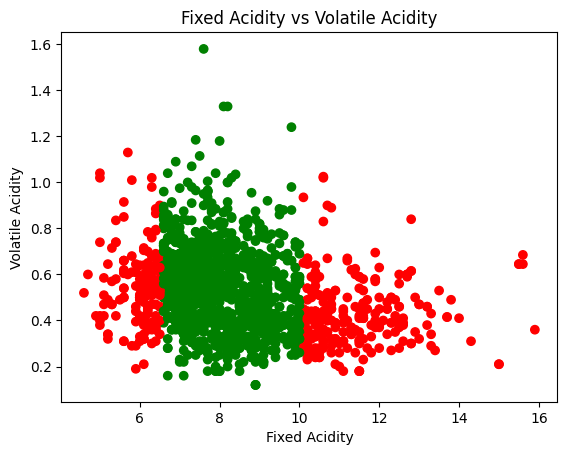

In [15]:
# Plot sepal_length vs sepal_width with color coding based on sepal_length standard deviation
mean_fixed_acidity = mean(features[0])
std_fixed_acidity = pstdev(features[0])

colors = ['red' if abs(x - mean_fixed_acidity) > std_fixed_acidity else 'green' for x in features[0]]
print(colors)
print(features[0])
print(features[1])

plt.scatter(features[0], features[1], c=colors)
plt.xlabel('Fixed Acidity')
plt.ylabel('Volatile Acidity')
plt.title('Fixed Acidity vs Volatile Acidity')

# Write the plot to a file
plt.savefig('/content/wine.png')

plt.show()

In [ ]:
# Save the stdev to a text file
stdev_strings = [str(stdev) for stdev in standard_dev]
big_stdev_string = ", ".join(stdev_strings)
stdev_text = open("/content/stdevs.txt", 'w')
stdev_text.write(big_stdev_string)
stdev_text.close()

In [ ]:
# Save the scaled features to a text file
feature_strings = []

for row in scaled_values.itertuples():
  feature_string = str(row[1:])
  feature_strings.append(feature_string[1:-1])

feature_string = "\n".join(feature_strings)

feature_text = open("/content/features.txt", 'w')
feature_text.write(feature_string)
feature_text.close()